# Objective

The objective of this project is to build a Machine Learning model for breast cancer prediction using medical diagnostic data. The project aims to analyze important features, preprocess the dataset, and improve prediction accuracy for classifying tumors as malignant or benign.

In [ ]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('breast-cancer.csv')

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


# Handling missing values

In [ ]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df.shape

(569, 32)

# Target Variable Encoding


In [ ]:
# Encode diagnosis column
df['target_num'] = df['diagnosis'].map({'B': 0, 'M': 1})

In [ ]:
# Exclude 'id' and 'target_num'
numeric_features = df.select_dtypes(include=['float64']).columns


# Correlation Analysis

In [ ]:
# Correlation of features with target variable
corr = df[numeric_features].corrwith(df['target_num']).sort_values(
    key=abs,
    ascending=False
)

print(corr)


concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
smoothness_se             -0.067016
fractal_dimension_mean    -0

In [ ]:
top_features = corr.head(10).index
print("Top features based on correlation with target:", list(top_features))


Top features based on correlation with target: ['concave points_worst', 'perimeter_worst', 'concave points_mean', 'radius_worst', 'perimeter_mean', 'area_worst', 'radius_mean', 'area_mean', 'concavity_mean', 'concavity_worst']


# Univariate Analysis

In [ ]:



# Summary statistics
summary = df[top6_features].describe().T
summary['skew'] = df[top6_features].skew()print(summary)

# Distribution plots
for col in top6_features:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

SyntaxError: invalid syntax (1305927508.py, line 3)

              count      mean       std     min     25%     50%     75%  \
radius_se     569.0  0.405172  0.277313  0.1115  0.2324  0.3242  0.4789   
perimeter_se  569.0  2.866059  2.021855  0.7570  1.6060  2.2870  3.3570   

                 max      skew   kurtosis  
radius_se      2.873  3.088612  17.686726  
perimeter_se  21.980  3.443615  21.401905  


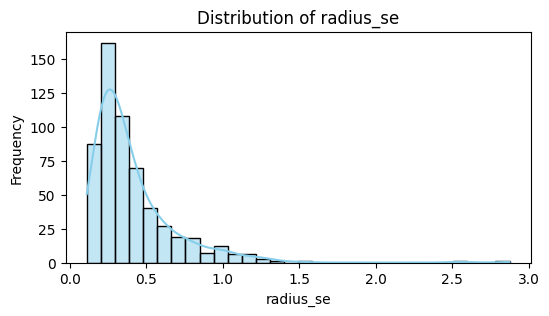

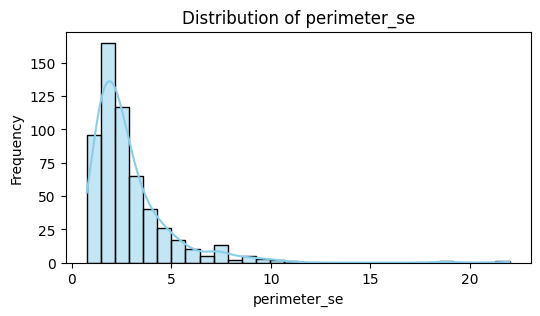

In [ ]:
# Assuming df is your dataframe
top2_features = ['radius_se', 'perimeter_se']

# Summary statistics
summary = df[top2_features].describe().T
summary['skew'] = df[top2_features].skew()
summary['kurtosis'] = df[top2_features].kurtosis()
print(summary)
for col in top2_features:
    plt.figure(figsize=(6,3))
    sns.histplot(df[col], kde=True, color='skyblue', bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Bivariate Analysis

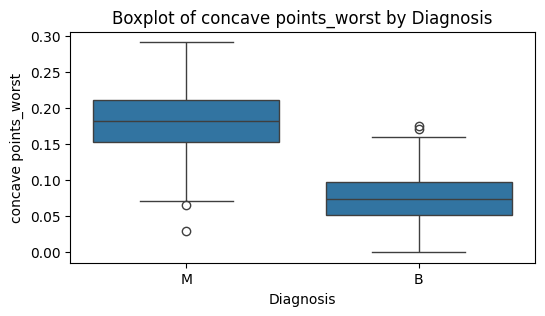

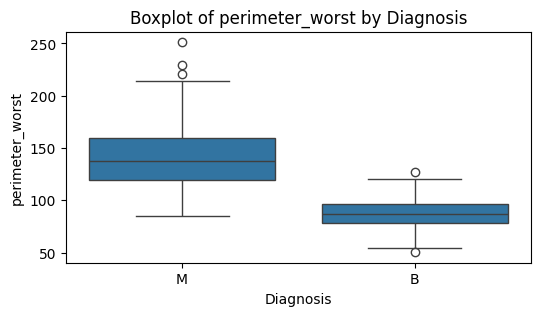

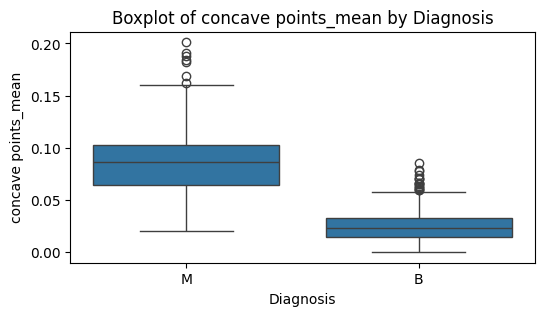

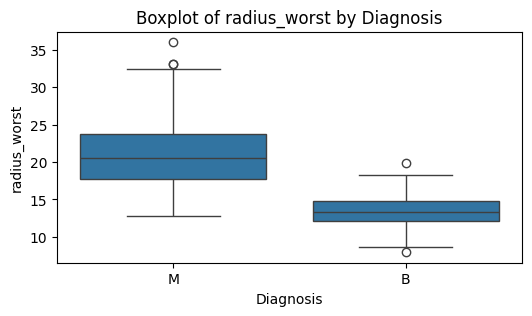

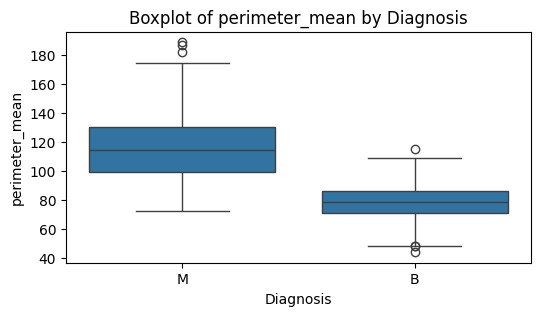

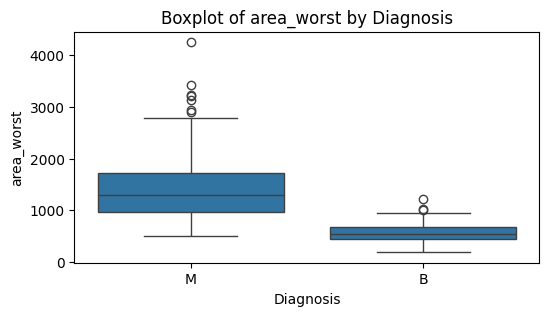

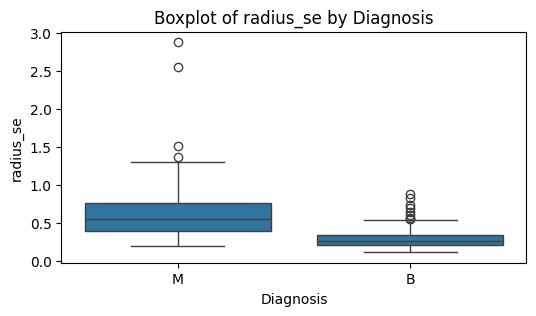

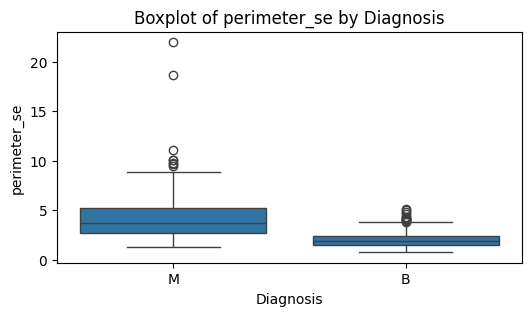

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 6 features (replace with your computed top6_features if different)
top6_features = ['concave points_worst', 'perimeter_worst', 'concave points_mean',
                 'radius_worst', 'perimeter_mean', 'area_worst','radius_se', 'perimeter_se'  ]

# Boxplot for each feature
for col in top6_features:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='diagnosis', y=col, data=df)
    plt.title(f'Boxplot of {col} by Diagnosis')
    plt.xlabel('Diagnosis')
    plt.ylabel(col)
    plt.show()


In [ ]:

#  Mean values grouped by diagnosis
df.groupby('diagnosis')[top6_features].mean()


,concave points_worst,perimeter_worst,concave points_mean,radius_worst,perimeter_mean,area_worst,radius_se,perimeter_se
diagnosis,,,,,,,,
B,0.074444,87.005938,0.025717,13.379801,78.075406,558.899440,0.284082,2.000321
M,0.182237,141.370330,0.087990,21.134811,115.365377,1422.286321,0.609083,4.323929


In [ ]:
df.groupby('diagnosis')['radius_se'].mean()


,radius_se
diagnosis,
B,0.284082
M,0.609083


In [ ]:

df.groupby('diagnosis')[ 'perimeter_se'].mean()

,perimeter_se
diagnosis,
B,2.000321
M,4.323929


In [ ]:
df['target_num'] = df['diagnosis'].map({'B':0, 'M':1})

corr = df[top6_features + ['target_num']].corr()['target_num'].sort_values(ascending=False)
print(corr)


target_num              1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_se               0.567134
perimeter_se            0.556141
Name: target_num, dtype: float64


# Multivariate Analysis

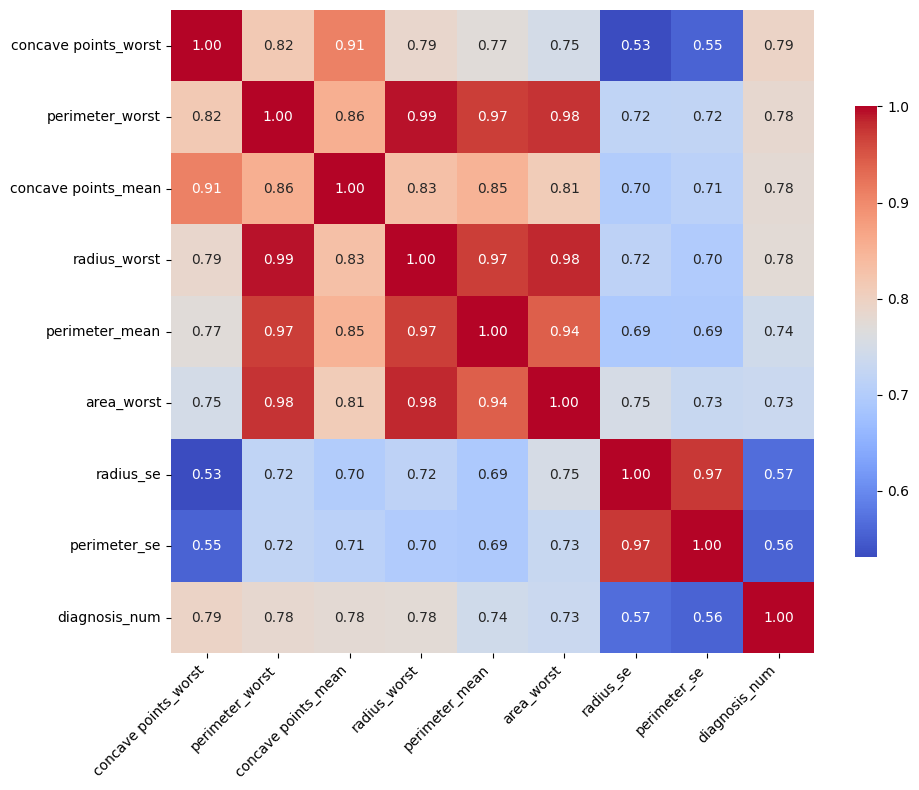

In [ ]:



# Your selected features
top_features = ['concave points_worst', 'perimeter_worst', 'concave points_mean',
                'radius_worst', 'perimeter_mean', 'area_worst', 'radius_se', 'perimeter_se']

# Convert diagnosis to numeric
df['diagnosis_num'] = df['diagnosis'].map({'B':0, 'M':1})

# Include diagnosis in the features for correlation
features = top_features + ['diagnosis_num']

# Compute correlation
corr_top = df[features].corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_top, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={'shrink':0.7})
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()




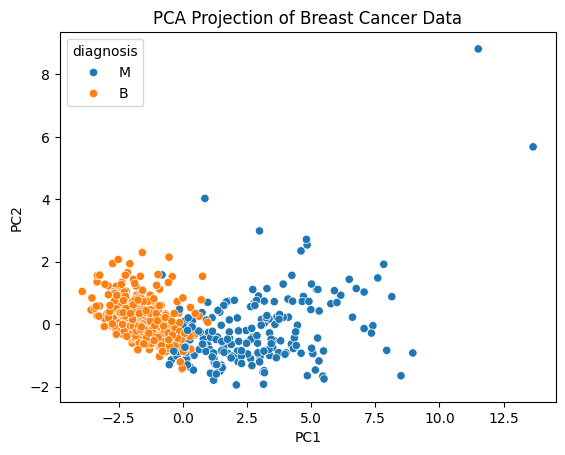

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Standardize features
X_scaled = StandardScaler().fit_transform(df[top6_features])

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create PCA dataframe
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['diagnosis'] = df['diagnosis']

# PCA scatter plot
sns.scatterplot(x='PC1', y='PC2', hue='diagnosis', data=pca_df)

plt.title("PCA Projection of Breast Cancer Data")
plt.show()


#Logistic Regression


=== Logistic Regression (Baseline) ===
Test Accuracy: 0.9649
[[71  1]
 [ 3 39]]
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


=== Logistic Regression (Class Weight Balanced) ===
Test Accuracy: 0.9737
[[71  1]
 [ 2 40]]
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        72
           1       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


=== Logistic Regression (Threshold = 0.4) ===
Test Accuracy: 0.9737
[[71  1]
 [ 2 40]]
              precision    recall  f1-score   support

           0       0.97     

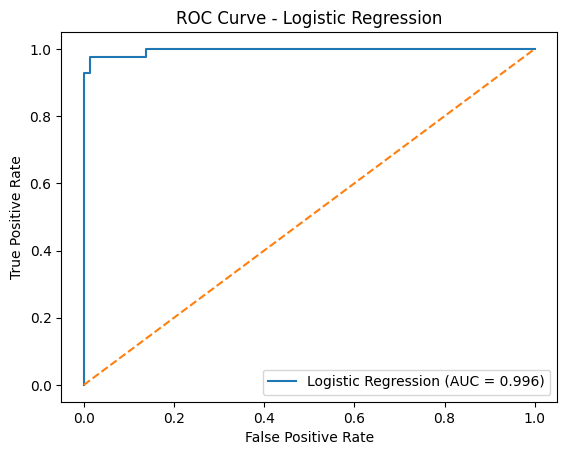


Logistic Regression AUC: 0.996


In [ ]:
# ---------------- IMPORT LIBRARIES ----------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    accuracy_score
)

# ---------------- LOAD DATA ----------------
df = pd.read_csv("breast-cancer.csv")

# ---------------- DEFINE FEATURES & TARGET ----------------
X = df.drop(columns=['id', 'diagnosis', 'target_num', 'diagnosis_num'], errors='ignore')
y = df['diagnosis'].map({'B': 0, 'M': 1})  # Encode target

# ---------------- TRAIN TEST SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------- FEATURE SCALING ----------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================================
# 1️⃣ BASELINE LOGISTIC REGRESSION
# ==========================================================

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression (Baseline) ===")
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

# ==========================================================
# 2️⃣ LOGISTIC REGRESSION WITH CLASS WEIGHT
# ==========================================================

lr_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)

y_pred_bal = lr_balanced.predict(X_test_scaled)
y_prob_bal = lr_balanced.predict_proba(X_test_scaled)[:, 1]

print("\n=== Logistic Regression (Class Weight Balanced) ===")
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_bal), 4))
print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))

# ==========================================================
# 3️⃣ THRESHOLD TUNING (0.4)
# ==========================================================

threshold = 0.4
y_pred_thresh = (y_prob_lr >= threshold).astype(int)

print("\n=== Logistic Regression (Threshold = 0.4) ===")
print("Test Accuracy:", round(accuracy_score(y_test, y_pred_thresh), 4))
print(confusion_matrix(y_test, y_pred_thresh))
print(classification_report(y_test, y_pred_thresh))

# ==========================================================
# 4️⃣ ROC CURVE
# ==========================================================

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
roc_auc_lr = auc(fpr_lr, tpr_lr)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {roc_auc_lr:.3f})')
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("\nLogistic Regression AUC:", round(roc_auc_lr, 4))

# KNeighbors

Best K Value: 3
Best Cross Validation Accuracy: 0.9692

Train Accuracy: 0.9846
Test Accuracy: 0.9386

Confusion Matrix:
 [[71  1]
 [ 6 36]]

Classification Report:
               precision    recall  f1-score   support

           B       0.92      0.99      0.95        72
           M       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



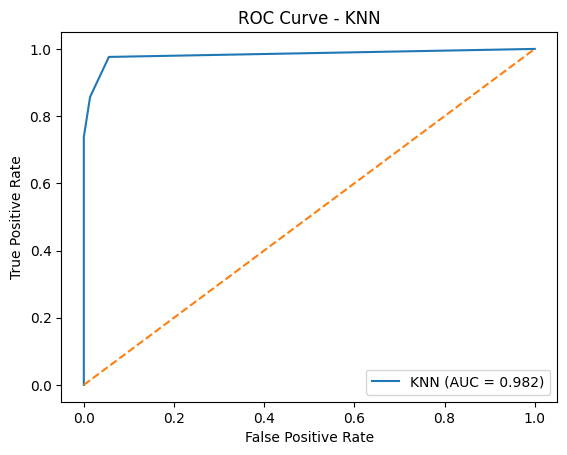


KNN AUC: 0.9825


In [ ]:
# ---------------- IMPORT LIBRARIES ----------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

# ---------------- LOAD CSV DATASET ----------------
df = pd.read_csv("breast-cancer.csv")

# ---------------- DEFINE X AND y ----------------
X = df.drop(
    columns=['id', 'diagnosis', 'target_num', 'diagnosis_num'],
    errors='ignore'
)

y = df['diagnosis']   # Keep labels as B / M

# ---------------- TRAIN TEST SPLIT ----------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ---------------- FEATURE SCALING ----------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================================
# FIND BEST K USING CROSS VALIDATION
# ==========================================================

k_range = range(1, 21)
cv_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy'
    )
    cv_scores.append(scores.mean())

best_k = k_range[np.argmax(cv_scores)]

print("Best K Value:", best_k)
print("Best Cross Validation Accuracy:", round(max(cv_scores), 4))

# ==========================================================
# TRAIN FINAL MODEL
# ==========================================================

final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train)

# ---------------- PREDICTIONS ----------------
y_pred = final_knn.predict(X_test_scaled)

# ---------------- TRAIN & TEST ACCURACY ----------------
print("\nTrain Accuracy:", round(final_knn.score(X_train_scaled, y_train), 4))
print("Test Accuracy:", round(final_knn.score(X_test_scaled, y_test), 4))

# ---------------- CONFUSION MATRIX ----------------
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# ---------------- CLASSIFICATION REPORT ----------------
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ==========================================================
# ROC CURVE + AUC
# ==========================================================

# Convert labels to binary for ROC (B=0, M=1)
y_test_binary = y_test.map({'B': 0, 'M': 1})

# Get probability for Malignant class ('M')
class_index = list(final_knn.classes_).index('M')
y_prob = final_knn.predict_proba(X_test_scaled)[:, class_index]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test_binary, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'KNN (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], '--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - KNN")
plt.legend()
plt.show()

print("\nKNN AUC:", round(roc_auc, 4))

In [ ]:

import streamlit as st
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# ==========================================
# LOAD DATASET
# ==========================================
df = pd.read_csv("breast-cancer.csv")

# ==========================================
# FEATURES AND TARGET
# ==========================================
# Remove unwanted columns if present
X = df.drop(columns=['id', 'diagnosis', 'target_num', 'diagnosis_num'], errors='ignore')

# Target column
y = df['diagnosis']

# Store feature names
feature_names = X.columns.tolist()

# ==========================================
# TRAIN TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ==========================================
# FEATURE SCALING
# ==========================================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# LOGISTIC REGRESSION MODEL
# ==========================================
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_scaled, y_train)

# ==========================================
# FIND BEST K VALUE FOR KNN
# ==========================================
k_range = range(1, 21)

cv_scores = []

for k in k_range:

    knn = KNeighborsClassifier(n_neighbors=k)

    scores = cross_val_score(
        knn,
        X_train_scaled,
        y_train,
        cv=5,
        scoring='accuracy'
    )

    cv_scores.append(scores.mean())

# Best K value
best_k = k_range[np.argmax(cv_scores)]

# ==========================================
# FINAL KNN MODEL
# ==========================================
knn_model = KNeighborsClassifier(n_neighbors=best_k)

knn_model.fit(X_train_scaled, y_train)

# ==========================================
# STREAMLIT UI
# ==========================================
st.title("Breast Cancer Prediction App")

st.write("Enter the feature values below")

# ==========================================
# USER INPUTS
# ==========================================
user_input = []

for feature in feature_names:

    value = st.number_input(
        f"Enter {feature}",
        value=float(X[feature].mean())
    )

    user_input.append(value)

# ==========================================
# PREDICTION BUTTON
# ==========================================
if st.button("Predict"):

    # Convert user input to dataframe
    input_df = pd.DataFrame(
        [user_input],
        columns=feature_names
    )

    # Scale input
    input_scaled = scaler.transform(input_df)

    # Logistic Regression Prediction
    lr_prediction = lr_model.predict(input_scaled)[0]

    # KNN Prediction
    knn_prediction = knn_model.predict(input_scaled)[0]

    # ======================================
    # DISPLAY RESULTS
    # ======================================
    st.subheader("Prediction Results")

    # Logistic Regression Result
    if lr_prediction == 'M':

        st.error(
            "Logistic Regression Result: Malignant (Cancerous)"
        )

    else:

        st.success(
            "Logistic Regression Result: Benign (Normal)"
        )

    # KNN Result
    if knn_prediction == 'M':

        st.error(
            "KNN Result: Malignant (Cancerous)"
        )

    else:

        st.success(
            "KNN Result: Benign (Normal)"
        )

# ==========================================
# SHOW BEST K VALUE
# ==========================================
st.write(f"Best K Value Used: {best_k}")

2026-05-08 11:39:32.652 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:39:32.820 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-05-08 11:39:32.821 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:39:32.822 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:39:32.824 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:39:32.825 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:39:32.827 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-08 11:39:32.831 Thread 'MainThread': mi

In [ ]:
!pip install streamlit


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 100.0 MB/s eta 0:00:00


# Conclusion

- KNN and Logistic Regression models were successfully used for breast cancer classification using medical diagnostic features.
- Logistic Regression with class weight balancing achieved the best performance with 97.37% test accuracy and improved malignant case prediction.
- The confusion matrix shows very low misclassification, correctly identifying most benign and malignant tumor cases with high precision and recall.
- Feature scaling, PCA, hyperparameter tuning, and class balancing significantly improved model performance and classification reliability for medical diagnosis.